# Phosphatase scanner result summary and motif finder

This project implements a post-HMM analysis pipeline for phosphatase detection, addressing the limitation that HMM-based scanners capture phosphatase-like folds but do not resolve whether key catalytic motifs are functionally intact. By combining hmmscan-based fold assignment with motif-level pattern matching, the pipeline distinguishes canonical motifs, relaxed variants, and degenerate fold remnants, enabling functional interpretation at the sequence level.

---

**Author:** Sara Wattabasombat

**Affiliation:** Department of Microbiology, Faculty of Medicine, Chiang Mai University

**Contact:** sara_watt@cmu.ac.th
**Date:** 2025-12-23

## Running the notebook

1. Click `Run all`
2. Go to `Main Program` section
3. You'll be prompted to upload 2 files
    - Upload a `.tab` output from Phosphatase scanner e.g. `<some name>.general.hmmscan.tab`
    - Upload `.fa` or `.fasta` file that you used in Phosphatase scanner.
4. You'll be promt to input the name of output file, there are 2 outputs.
    - FASTA output - This file will contain all the sequence extracted from input which matched as Phosphatase.
    - TSV output - This is a tab seperated file which summerize matched sequence and motif pattern match.

## Setup the environment

### Import required libraries

In [24]:
%pip install biopython

import re
from os import PathLike
from typing import Tuple
import pandas as pd
from tqdm import tqdm
from Bio import SeqIO
# from google.colab import files

Note: you may need to restart the kernel to use updated packages.


In [ ]:
# @title
__author__ = "Sara Wattanasombat"
__date__ = "2025-01-21"
__version__ = "1.0.0"
__project__ = "Phosphatase scanner result summary and motif finder"

### Mapping values

In [26]:
# @title
# E-value cutoff for HMM scan confidence.
E_VALUE_CUTOFF = 1e-6
# Map "HMM Name" to "Fold family".
FOLD_DICT = {
        'Alk_phosphatase': 'ALK',
        'CPDc_SM00577': 'HAD',
        'Chronophin_1': 'HAD',
        'Chronophin_2': 'HAD',
        'DSPc': 'CC1',
        'DSPc_SM00195': 'CC1',
        'DUF442': 'Unknown',
        'His_Phos_1': 'HP',
        'His_Phos_2': 'HP',
        'Init_tRNA_PT': 'CC1',
        'LMWPc': 'CC2',
        'LMWPc_SSU72': 'CC2',
        'LMWPc_SSU72_ArsC': 'CC2',
        'MDP_1': 'HAD',
        'MDP_2': 'HAD',
        'Myotub-related': 'CC1',
        'NIF': 'HAD',
        'PP2Ac_SM00156': 'PPPL',
        'PP2C': 'PPM',
        'PP2C_2': 'PPM',
        'PP2C_SIG_SM00331': 'PPM',
        'PP2Cc_SM00332': 'PPM',
        'PPM_PTC7': 'PPM',
        'PPM_PTC7_SpoIIE': 'PPM',
        'PPM_PTC7_motif': 'PPM',
        'PPP_1': 'PPPL',
        'PPP_2': 'PPPL',
        'PPP_3': 'PPPL',
        'PPP_4': 'PPPL',
        'PPP_5_Dcr2': 'PPPL',
        'PTEN_1': 'CC1',
        'PTPc_DSPc_SM00012': 'CC1',
        'PTPc_motif_SM00404': 'CC1',
        'PTPlike_phytase': 'CC1',
        'RHOD_SM00450': 'CC3',
        'RPAP2_Rtr1': 'RTR1',
        'Ssu72': 'CC2',
        'Y_phosphatase': 'CC1',
        'Y_phosphatase2': 'CC1',
        'Y_phosphatase3': 'CC1',
        'PPM_PTC7_SpoIIE_motif': 'PPM',
        'SpoIIE': 'PPM',
    }



### Define motif pattern

For each fold family (e.g. CC1, PPM, HP), multiple regex patterns are provided that represent different evolutionary states of the same motif:

| match_type | Description |
|-|-|
| exact | canonical, functionally conserved motif |
| relaxed | conservative substitutions at non-critical positions |
| anchor | partial motifs capturing key catalytic or structural residues |
| remnant / degenerate | degraded motifs consistent with fold remnants or loss of function |

Each pattern is annotated with metadata:

- `motif`: fold family
- `match_type`: confidence / degradation level
- `description`: biological interpretation
- `connected`: whether the motif consists of spatially separated but functionally linked sub-motifs
- `part`: which portion of a connected motif is matched (full, A, anchor)

In [59]:
# @title
MOTIF_PATTERNS = {
    "CC1":   [
        {
            "pattern": r"HC[A-Z]{5}R",
            "match_type": "exact",
            "motif": "CC1",
            "description": "Canonical CC1 motif",
        },
        {
            "pattern": r"HC[A-Z]{5}[A-Z]",
            "match_type": "relaxed",
            "motif": "CC1",
            "description": "Conserved canonical HC motif with mutated C-terminal arginine",
        },
        {
            "pattern": r"[A-Z]C[A-Z]{5}R",
            "match_type": "relaxed",
            "motif": "CC1",
            "description": "His mutated at position 1",
        },
        {
            "pattern": r"H[A-Z]{6}R", # only R conserved
            "match_type": "degenerate",
            "motif": "CC1",
            "description": "Mutated C at position 2",
        },
    ],
    "CC2": [
        {
            "pattern": r"(V|I)C[A-Z]{5}R",
            "match_type": "exact",
            "motif": "CC2",
            "description": "Canonical CC2 motif",
        },
        {
            "pattern": r"(V|I)C[A-Z]{5}K",
            "match_type": "degenerate",
            "motif": "CC2",
            "description": "Arg→Lys substitution at position 8",
        },
    ],
    "CC3": [
        {
            "pattern": r"HC[A-Z]{5}R",
            "match_type": "exact",
            "motif": "CC3",
            "description": "Canonical CC3 motif",
        },
        {
            "pattern": r"HC[A-Z]{5}[A-Z]",
            "match_type": "relaxed",
            "motif": "CC3",
            "description": "Conserved canonical HC motif with mutated C-terminal arginine",
        },
        {
            "pattern": r"[A-Z]C[A-Z]{5}R",
            "match_type": "relaxed",
            "motif": "CC3",
            "description": "N-terminal residue mutated",
        },
        {
            "pattern": r"H[A-Z]{6}R", # only R conserved
            "match_type": "degenerate",
            "motif": "CC3",
            "description": "Mutated C at position 2",
        },
        {
            "pattern": r"[A-Z]C[A-Z]{5}K", # only C conserved
            "match_type": "degenerate",
            "motif": "CC3",
            "description": "Conserved C with Arg→Lys substitution at position 8",
        },
    ],
    "PPM":   [
        {
            "pattern": r"(([NR][A-Z]{4}D).*?(D[ND]))",
            "match_type": "exact",
            "motif": "PPM",
            "description": "Canonical PPM connected motif",
            "connected": True,
            "part": "full",
        },
        {
            "pattern": r"((DG[A-Z]{2}G).*?(D[ND]))",
            "match_type": "relaxed",
            "motif": "PPM",
            "description": "Alternative N-terminal PPM anchor",
            "connected": True,
            "part": "full",
        },
        {
            "pattern": r"[NR][A-Z]{4}D",
            "match_type": "anchor",
            "motif": "PPM",
            "description": "PPM N-terminal anchor only",
            "connected": False,
            "part": "A",
        },
        {
            "pattern": r"DG[A-Z]{2}G",
            "match_type": "anchor",
            "motif": "PPM",
            "description": "PPM alternative N-terminal anchor",
            "connected": False,
            "part": "A",
        },
        {
            "pattern": r"(([ND][A-Z]{4}D).*?(D[ND]))",
            "match_type": "remnant",
            "motif": "PPM",
            "description": "PPM fold remnant: acidic anchors retained with degraded chemistry",
            "connected": True,
            "part": "full",
        },
        {
            "pattern": r"DGL[WFY][DE]",
            "match_type": "remnant",
            "motif": "PPM",
            "description": "Degenerate PPM signature",
            "connected": False,
            "part": "anchor",
        },
    ],
    "PPPL": [
        {
            "pattern": r"GD[STAV]HG",
            "match_type": "exact",
            "motif": "PPPL",
            "description": "Core PPPL catalytic GDxHG motif",
            "connected": False,
            "part": "full",
        },
        {
            "pattern": r"GD[A-Z]HG[A-Z]{2}D",
            "match_type": "exact",
            "motif": "PPPL",
            "description": "Extended PPPL metal-binding motif",
            "connected": False,
            "part": "full",
        },
        {
            "pattern": r"GD[A-Z]VDRG",
            "match_type": "relaxed",
            "motif": "PPPL",
            "description": "Extended PPPL variant",
            "connected": False,
            "part": "full",
        },
        {
            "pattern": r"G[DN][A-Z]HG",
            "match_type": "relaxed",
            "motif": "PPPL",
            "description": "Divergent PPPL catalytic loop",
            "connected": False,
            "part": "core",
        },
        {
            "pattern": r"GN[HQ]E",
            "match_type": "remnant",
            "motif": "PPPL",
            "description": "Degenerate PPPL remnant",
            "connected": False,
            "part": "anchor",
        },
        {
            "pattern": r"G[A-Z][A-Z]HG",
            "match_type": "remnant",
            "motif": "PPPL",
            "description": "Severely degenerate GDxHG motif",
            "connected": False,
            "part": "anchor",
        },
    ],
    "RTR1": [
        {
            "pattern": r"H[A-Z]{2}H[A-Z]{10,30}[DE]",
            "match_type": "canonical",
            "motif": "RTR1",
            "description": "Canonical RTR1 His–His–acid catalytic motif",
            "connected": False,
            "part": "core",
        },
        {
            "pattern": r"H[A-Z]H[A-Z]{5,40}[DE]",
            "match_type": "relaxed",
            "motif": "RTR1",
            "description": "Divergent but likely active RTR1 motif",
            "connected": False,
            "part": "core",
        },
        {
            "pattern": r"[HQ][A-Z]H[A-Z]{10,40}[DE]",
            "match_type": "relaxed",
            "motif": "RTR1",
            "description": "Conservatively substituted RTR1 motif",
            "connected": False,
            "part": "core",
        },
        {
            "pattern": r"H[A-Z]{10,50}[DE]",
            "match_type": "remnant",
            "motif": "RTR1",
            "description": "Degenerate RTR1 remnant",
            "connected": False,
            "part": "anchor",
        },
    ],
    "HAD":   [
        {
            "pattern": r"D[A-Z]D[A-Z]T",
            "match_type": "exact",
            "motif": "HAD",
            "description": "Canonical HAD catalytic motif",
            "connected": False,
            "part": "full",
        },
    ],
    "HP":    [
        {
            "pattern": r"((RHG[A-Z]R[A-Z]P).*?(HD))",
            "match_type": "exact",
            "motif": "HP",
            "description": "Canonical HP connected motif",
            "connected": True,
            "part": "full",
        },
        {
            "pattern": r"((RHG[A-Z]R[A-Z]P).*?(H[TQ]))",
            "match_type": "degenerate",
            "motif": "HP",
            "description": "Degenerate HP remnant H-G core preserved with degraded downstream motif (His followed by Thr / Gln)",
            "connected": True,
            "part": "full",
        },
        {
            "pattern": r"RHG[A-Z]R[A-Z]P",
            "match_type": "remnent",
            "motif": "HP",
            "description": "HP N-terminal anchor only",
            "connected": False,
            "part": "A",
        },
        {
            "pattern": r"R?HG[A-Z]{3}P?",
            "match_type": "remnant",
            "motif": "HP",
            "description": "Degenerate HP remnant without downstream motif",
        },
    ],
    "Alk":   [
        {
            "pattern": r"[IV][A-Z]DS[GAS][GASC][GAST][GA]T",
            "match_type": "exact",
            "motif": "Alk",
            "description": "Canonical Alk catalytic motif",
            "connected": False,
            "part": "full",
        },
    ],
}

### Define helper functions

In [53]:
# @title
def read_hmmscan_tblout(filepath: str| PathLike):
    """
    Read an hmmscan --tblout file into a pandas DataFrame.

    Skips comment lines (#) and parses the standard 18-column HMMER output.
    Returns a DataFrame with column names matching the hmmscan manual.
    """
    colnames = [
        "target_name", "target_accession",
        "query_name", "query_accession",
        "full_seq_Evalue", "full_seq_score", "full_seq_bias",
        "best_dom_Evalue", "best_dom_score", "best_dom_bias",
        "exp", "reg", "clu", "ov", "env", "dom", "rep", "inc",
        "description_of_target"
    ]
    numeric_cols = [
        "full_seq_Evalue", "full_seq_score", "full_seq_bias",
        "best_dom_Evalue", "best_dom_score", "best_dom_bias",
        "exp", "reg", "clu", "ov", "env", "dom", "rep", "inc"
    ]

    _df = pd.read_csv(
        filepath,
        comment="#",
        sep='\\s+',
        names=colnames,
        usecols=range(len(colnames))  # ignore any trailing extra whitespace
    )
    # convert numeric columns to floats/ints where appropriate
    _df[numeric_cols] = _df[numeric_cols].apply(pd.to_numeric, errors="coerce")

    return _df


def classify_hmmscan(hmmscan_tbldf: pd.DataFrame, min_evalue=1e-6):
    """
    Classify HMMER hmmscan hits into confidence categories.

    This function takes the tabular output from `read_hmmscan_tblout`, filters out
    hits with very weak E-values, and assigns each hit to one of the following
    categories based on heuristic thresholds:

        - "High-confidence"
        - "Probable"
        - "Weak"
        - "Fragmentary"
        - "Ambiguous"
        - "No match"

    Parameters
    ----------
    hmmscan_tbldf : pandas.DataFrame
        DataFrame containing hmmscan results, as formatted by
        `read_hmmscan_tblout`. Must include the following columns:
        ``["full_seq_Evalue", "best_dom_Evalue", "best_dom_score", "best_dom_bias",
        "exp", "clu", "ov", "env", "rep", "inc"]``.
    min_evalue : float, optional
        Minimum full-sequence E-value threshold for filtering hits (default = 1e-6).

    Returns
    -------
    pandas.DataFrame
        A copy of the input DataFrame with an additional column ``"confidence"``
        containing the assigned category for each hit.

    Raises
    ------
    BaseException
        If one or more of the required columns are missing from the input DataFrame.

    Notes
    -----
    The classification scheme is heuristic and may need to be adjusted for
    specific datasets or applications.
    """
    _df = hmmscan_tbldf.copy()
    # Filter out very weak hits (full_seq_Evalue < 1e-6)
    _df = _df.loc[_df['full_seq_Evalue'] < min_evalue]
    expected_cols = [
        "full_seq_Evalue",
        "best_dom_Evalue", "best_dom_score", "best_dom_bias",
        "exp", "clu", "ov", "env", "rep", "inc",
    ]
    # Check if all of the required columns exists in the input dataframe.
    if set(expected_cols).intersection(set(_df.columns)) != set(expected_cols):
        raise BaseException('classify_hmmscan: Expected column(s) not found in dataframe.')

    def classify(row):
        full_e = row["full_seq_Evalue"]
        dom_e = row["best_dom_Evalue"]
        score = row["best_dom_score"]
        bias = row["best_dom_bias"]
        inc = row["inc"]
        rep = row["rep"]
        exp = row["exp"]
        env = row["env"]
        clu = row["clu"]
        ov = row["ov"]

        # Decision tree
        if full_e <= 1e-5:
            if inc >= 1:
                if dom_e <= 1e-3 and bias < 0.1 * score:
                    return "High-confidence"
                else:
                    return "Probable"
            else:
                if dom_e <= 1e-3 and rep >= 1:
                    return "Probable"
                elif exp >= 0.5 and env > 0:
                    return "Weak"
                else:
                    return "Fragmentary"
        else:
            if dom_e <= 1e-3 and inc >= 1:
                return "Probable"
            elif clu > 0 or ov > 0:
                return "Ambiguous"
            elif rep >= 1 and dom_e <= 1e-2:
                return "Weak"
            else:
                return "No match"

    _df["confidence"] = _df.apply(classify, axis=1)
    return _df

def find_motif(sequence, pattern_list):
    for i, motif in enumerate(pattern_list):
        matches = []
        pattern = motif.get('pattern')
        for m in re.finditer(pattern, str(sequence)):
            matches.append({
                "pattern": str(pattern),
                "match_type": motif.get('match_type'),
                "description": motif.get('description'),
                "match": m.group(),       # the actual substring
                "start": m.start(),       # 0-based start index
                "end": m.end()            # 0-based end index (exclusive)
            })
        if len(matches) >= 1:
            return matches
            break
        if i == len(pattern_list)-1:
            return None

def get_args(handler='input') -> Tuple[str | PathLike, str | PathLike, str | PathLike]:
    match handler:
        case 'input':
            args_hmmscan_tblout = input('Path to hmmscan --tblout file (a file with .tab extension i) ')
            args_fasta_file = input('Path to input FASTA file: ')
        case 'colab_upload':
            print('Upload hmmscan --tblout file')
            args_hmmscan_tblout = list(files.upload().keys())[0]
            print('')
            print('Upload FASTA file containing all sequences used in HMM scan')
            args_fasta_file = list(files.upload().keys())[0]

    print('')
    args_match_output_fa_file = input('Path to output FASTA file for HMM matched sequences: ')
    print('')
    args_match_tsv_output_file = input('Path to output motif pattern match summary: ')
    if not args_match_output_fa_file.endswith('.fa'):
      args_match_output_fa_file += '.fa'
    if not args_match_tsv_output_file.endswith('.tsv'):
      args_match_tsv_output_file += '.tsv'
    return (
        args_hmmscan_tblout,
        args_fasta_file,
        args_match_output_fa_file,
        args_match_tsv_output_file
    )


## Main Program

### 1. Input handling

The script collects paths to the hmmscan --tblout file, the original FASTA file, and output files (FASTA + TSV). Input can be provided interactively or via Google Colab upload.

### 2. HMM hit filtering and classification

The hmmscan table is parsed, filtered by an E-value cutoff, and annotated with fold family assignments. For each query sequence, only the best HMM hit (lowest E-value, highest score) is retained.

Sequences with a retained HMM hit are annotated in the FASTA header with the predicted fold family and written to an output FASTA file.

### 3. Motif pattern matching

For sequences with known fold families, motif-specific regex patterns are applied to confirm canonical motifs, detect relaxed or degenerate variants,and localize conserved or remnant residues.

### 4. Summerize result

All motif matches (or explicit “no match” cases) are collected into a table summarizing:

- sequence ID and sequence
- fold family and HMM confidence
- motif pattern, match type, and positional information


In [29]:
# 1. Input handling
hmmscan_tblout_file, fasta_file, match_output_fa_file, match_tsv_output_file = get_args('input')

In [60]:
df = read_hmmscan_tblout(hmmscan_tblout_file)

# 2. HMM hit filtering and classification
df = df.loc[df['full_seq_Evalue'] < E_VALUE_CUTOFF].reset_index(drop=True)
df = classify_hmmscan(df)
best_hits = (
    df.sort_values(
        ['query_name', 'full_seq_Evalue', 'full_seq_score'],
        ascending=[True, True, False]
    )
    .groupby('query_name', as_index=False)
    .head(1)
)

best_hits_map = best_hits.set_index('query_name').to_dict('index')

sequences = SeqIO.parse(fasta_file, 'fasta')
matched_sequences = []

# 3. Motif pattern matching
all_pattern_matches = []
for seq in tqdm(sequences, desc="Processing sequences", mininterval=0.5):
    data = best_hits_map.get(seq.id)
    if data:
        fold_family = FOLD_DICT.get(data["target_name"], 'unknown')
        seq.description += f' fold_family={fold_family}'
        matched_sequences.append(seq)
        if fold_family != 'unknown':
            motif_pattern_match = find_motif(seq.seq, MOTIF_PATTERNS.get(fold_family, []))
            if motif_pattern_match:
                for match in motif_pattern_match:
                    all_pattern_matches.append({
                        "sequence_id": seq.id,
                        "sequence": str(seq.seq),
                        "motif": fold_family,
                        "HMM confidence": data.get('confidence'),
                        "e-value": f"{data.get('full_seq_Evalue'):.2e}",
                        "Motif confidence e-value": f"{data.get('full_seq_Evalue'):.2e}",
                        **match
                    })
            else:
                all_pattern_matches.append({
                    "sequence_id": seq.id,
                    "sequence": str(seq.seq),
                    "motif": fold_family,
                    "HMM confidence": data.get('confidence'),
                    "e-value": f"{data.get('full_seq_Evalue'):.2e}",
                    "pattern": None,
                    "match_type": "No Match",
                    "match": None,
                    "description": f"No evidence of canonical or remnent of {fold_family}",
                    "start": None,
                    "end": None
                })

# 4. Summerize result
n_matched_sequnece = SeqIO.write(matched_sequences, match_output_fa_file, 'fasta')
print(f'Saved {n_matched_sequnece} sequences to {match_output_fa_file}')
pattern_match_summary = pd.DataFrame(all_pattern_matches)
pattern_match_summary.to_csv(match_tsv_output_file, sep='\t', index=None)

Processing sequences: 7428it [00:00, 59294.62it/s]

Saved 76 sequences to /mnt/sdb/SOFTWARE/phosphatase-scanner/test/UP000010091_CnH99.fasta.general.hit_sequence.fa


## Visualize output

In [31]:
pattern_match_summary.head()

,sequence_id,sequence,motif,HMM confidence,e-value,Motif confidence e-value,pattern,match_type,description,match,start,end
0,sp|O42773|PP2B1_CRYNH,MASPATQTANAIAAINNRSNLVIPEIDFTQHQLENGEIVSTTERVI...,PPPL,High-confidence,1.80e-104,1.80e-104,GD[A-Z]VDRG,relaxed,Extended PPPL variant,GDYVDRG,146.0,153.0
1,tr|J9VLG2|J9VLG2_CRYN9,MDPRRRHNQRPPPPSSSLPPNPAAYNAPPNSYGGSYPDARQYQGHN...,CC2,High-confidence,6.80e-81,6.80e-81,(V|I)C[A-Z]{5}R,exact,Canonical CC2 motif,VCASNNNR,191.0,199.0
2,tr|J9VLG2|J9VLG2_CRYN9,MDPRRRHNQRPPPPSSSLPPNPAAYNAPPNSYGGSYPDARQYQGHN...,CC2,High-confidence,6.80e-81,6.80e-81,(V|I)C[A-Z]{5}R,exact,Canonical CC2 motif,VCDDLLTR,300.0,308.0
3,tr|J9VSQ9|J9VSQ9_CRYN9,MSMLPPKSPSVKRFTQNTEKRPTSPSPSSLLMNLNTPSLAAPKQPK...,HP,High-confidence,4.90e-76,NaN,None,No Match,NaN,None,NaN,NaN
4,tr|J9VSW3|J9VSW3_CRYN9,MPIAISTSQSSLAGSPPAPAPLVPPAPRNPVRLSVAARDHPQPSAG...,RTR1,High-confidence,9.50e-20,NaN,None,No Match,NaN,None,NaN,NaN


### Make a plot

In [ ]:
# @title
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

FOLD_COLORS = {
    "CC1": "#1f77b4",   # blue
    "CC2": "#2ca02c",   # green
    "CC3": "#9467bd",   # purple
    "PPM": "#d62728",   # red
    "PPPL": "#ff7f0e",  # orange
    "HP": "#8c564b",    # brown
    "HAD": "#17becf",   # cyan
    "Alk": "#7f7f7f",   # gray
    "unknown": "#c7c7c7",
}

MATCH_TYPE_SHADE = {
    "exact": 0.75,
    "relaxed": 0.6,
    "partial": 0.45,
    "anchor": 0.45,
    "remnant": 0.25,
    "degenerate": 0.25,
}

def shade_color(color, alpha):
    rgb = list(mcolors.to_rgb(color))
    rgb.append(alpha)
    return tuple(rgb)

def add_smart_callouts(
    ax,
    wedges,
    labels,
    r_outer=1.35,
    r_label=1.9,
    top_angle=75,
    bottom_angle=285,
    jitter_xy=0.06,
    min_dy=0.08,
    seed=42,
):
    """
    Place callout labels with Word-like autoplacement:
    - ideal anchor positions
    - small XY jitter
    - vertical collision avoidance
    - elbow leader lines
    """

    rng = np.random.default_rng(seed)

    items = []
    for wedge, label in zip(wedges, labels):
        angle = ((wedge.theta1 + wedge.theta2) / 2) % 360
        angle_rad = np.deg2rad(angle)

        x = np.cos(angle_rad)
        y = np.sin(angle_rad)

        if top_angle <= angle <= (180 - top_angle):
            zone = "top"
        elif (180 + top_angle) <= angle <= bottom_angle:
            zone = "bottom"
        elif x >= 0:
            zone = "right"
        else:
            zone = "left"

        items.append({
            "label": label,
            "angle_rad": angle_rad,
            "x": x,
            "y": y,
            "zone": zone,
        })

    def place_zone(zone_items, zone):
        """
        zone ∈ {"left", "right", "top", "bottom"}
        """

        if not zone_items:
            return

        if zone in ("left", "right"):
            zone_items.sort(key=lambda i: -i["y"])   # top → bottom
        else:
            zone_items.sort(key=lambda i: i["x"])    # left → right

        n = len(zone_items)

        if zone in ("top", "bottom"):
            spread = 2.0
            primary_targets = np.linspace(-spread, spread, n)
        else:
            primary_targets = None  # determined dynamically

        placed_primary = []

        for idx, item in enumerate(zone_items):
            ang = item["angle_rad"]

            # ---- Anchor at wedge ----
            x0 = np.cos(ang) * r_outer
            y0 = np.sin(ang) * r_outer

            # ---- Pivot ----
            x1 = np.cos(ang) * (r_outer + 0.15)
            y1 = np.sin(ang) * (r_outer + 0.15)

            # ---- Ideal label position ----
            if zone == "right":
                x2 = r_label
                y2 = y1
                ha = "left"
                primary = y2
            elif zone == "left":
                x2 = -r_label
                y2 = y1
                ha = "right"
                primary = y2
            elif zone == "top":
                x2 = primary_targets[idx]
                y2 = r_label
                ha = "center"
                primary = x2
            else:  # bottom
                x2 = primary_targets[idx]
                y2 = -r_label
                ha = "center"
                primary = x2

            # ---- Word-like jitter ----
            if zone in ("left", "right"):
                y2 += rng.uniform(-jitter_xy, jitter_xy)
            else:
                x2 += rng.uniform(-jitter_xy, jitter_xy)
                y2 += rng.uniform(-jitter_xy, jitter_xy)

            # ---- Collision avoidance (primary axis only) ----
            for p in placed_primary:
                if abs(primary - p) < min_dy:
                    primary += np.sign(primary - p) * min_dy

            # Apply corrected primary axis back
            if zone in ("left", "right"):
                y2 = primary
            else:
                x2 = primary

            placed_primary.append(primary)

            # ---- Draw elbow ----
            ax.plot([x0, x1], [y0, y1], lw=0.8, c='black')
            ax.plot([x1, x2], [y1, y2], lw=0.8,  c='black')

            ax.text(
                x2,
                y2,
                item["label"],
                ha=ha,
                va="center",
                fontsize=8,
            )


    # ---- Apply per zone ----
    place_zone([i for i in items if i["zone"] == "right"], "right")
    place_zone([i for i in items if i["zone"] == "left"], "left")
    place_zone([i for i in items if i["zone"] == "top"], "top")
    place_zone([i for i in items if i["zone"] == "bottom"], "bottom")

def plot_fold_family_match_type_hierarchy(
    df,
    fold_col="fold_family",
    match_col="match_type",
    title="Fold family → match type proportions",
):
    """
    Plot a nested circular (donut) chart:
      - inner ring: fold families
      - outer ring: match types within each fold family
    """

    # Aggregate data
    fold_counts = df[fold_col].value_counts()

    grouped = (
        df.groupby([fold_col, match_col])
        .size()
        .reset_index(name="count")
    )

    # Inner ring
    inner_sizes = fold_counts.values
    inner_labels = fold_counts.index.tolist()
    inner_colors = [
        FOLD_COLORS.get(fold, FOLD_COLORS["unknown"])
        for fold in inner_labels
    ]

    # Outer ring
    outer_sizes = []
    outer_labels = []
    outer_colors = []
    for fold in inner_labels:
        subset = grouped[grouped[fold_col] == fold]
        base = FOLD_COLORS.get(fold, FOLD_COLORS["unknown"])

        for _, row in subset.iterrows():
            shade = MATCH_TYPE_SHADE.get(row[match_col], 0.4)
            outer_colors.append(shade_color(base, shade))

    for fold in inner_labels:
        subset = grouped[grouped[fold_col] == fold]
        for _, row in subset.iterrows():
            outer_sizes.append(row["count"])
            outer_labels.append(f"{fold} / {row[match_col]}")

    fig, ax = plt.subplots()

    # Inner donut
    ax.pie(
        inner_sizes,
        labels=inner_labels,
        radius=1.0,
        startangle=90,
        labeldistance=0.4,
        colors=inner_colors,
        wedgeprops=dict(width=0.3, edgecolor="white"),
    )

    # Outer donut (no labels here)
    wedges_outer, _ = ax.pie(
        outer_sizes,
        radius=1.35,
        startangle=90,
        colors=outer_colors,
        wedgeprops=dict(width=0.3, edgecolor="white"),
    )

    # --- Callout labels ---
    add_smart_callouts(
        ax,
        wedges_outer,
        outer_labels,
        r_outer=1.35,
        r_label=1.9,
    )

    ax.set_title(title)
    ax.axis("equal")
    plt.tight_layout()
    plt.show()

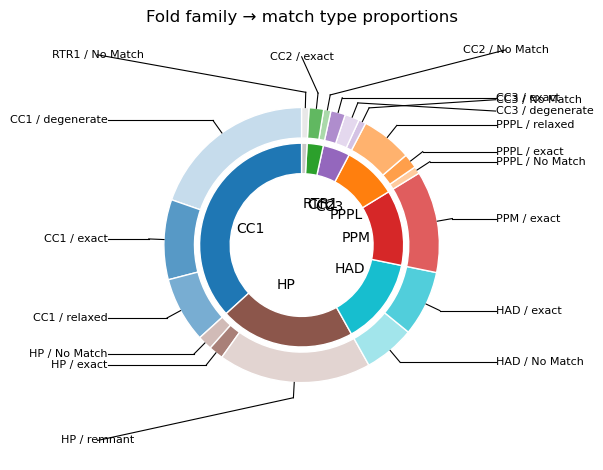

In [33]:
plot_fold_family_match_type_hierarchy(pattern_match_summary, 'motif')

# Interactive report

The donut plot above looks ok but may not be properly formatted to your liking, this is due to manual work required to config Matplotlib to place elements in propper location.

This section will create a fully interactive report in HTML format.

Please make sure that you have the `template.j2` file and set the variable `HTML_REPORT_TEMPLATE_DIR` accordingly before running the script.

In [ ]:
# Input the directory that contains `template.j2` file
# i.e. if template.j2 is at /home/user/sacnner/report/template.j2
# You should input /home/user/sacnner/report
HTML_REPORT_TEMPLATE_DIR = "..."

In [ ]:
from datetime import datetime
from collections import defaultdict
from jinja2 import Environment, FileSystemLoader

def safe_int(x):
    if pd.isna(x):
        return None
    return int(x)

def highlight_sequence(sequence, spans):
    seq = list(sequence)
    
    for start, end in spans:
        start -= 1  # convert to 0-based
        end -= 1
        seq[start] = f"<span class='seq-highlight'>{seq[start]}"
        seq[end] = f"{seq[end]}</span>"

    return "".join(seq)

def render_report_html(data):
    env = Environment(
        loader=FileSystemLoader(
            HTML_REPORT_TEMPLATE_DIR
        )
    )
    template = env.get_template("template.j2")

    # Fold-family summary
    grouped = (
        data.groupby(['motif', 'match_type'])
        .size()
        .reset_index(name='value')
    )

    fold_family_counts = {
        "name": "root",
        "children": []
    }

    motif_map = defaultdict(list)
    for row in grouped.itertuples(index=False):
        motif_map[row.motif].append({
            "name": row.match_type.capitalize(),
            "value": int(row.value)
        })

    for motif, children in motif_map.items():
        fold_family_counts["children"].append({
            "name": motif,
            "children": children
        })

    # Group matches per sequence
    grouped_sequences = defaultdict(lambda: {
        "sequence_id": None,
        "sequence": None,
        "motif": None,
        "HMM confidence": None,
        "e-value": None,
        "sequence_html": None,
        "matches": [],
        "n_matches": 0
    })

    for _, row in data.iterrows():
        key = (row["sequence_id"], row["motif"])

        entry = grouped_sequences[key]
        entry["sequence_id"] = row["sequence_id"]
        entry["sequence"] = row["sequence"]
        entry["motif"] = row["motif"]
        entry["HMM confidence"] = row["HMM confidence"]
        entry["e-value"] = row["e-value"]

        entry["matches"].append({
            "pattern": row["pattern"],
            "match": row["match"],
            "start": safe_int(row["start"]),
            "end": safe_int(row["end"]),
            "match_type": row["match_type"].capitalize(),
            "description": row["description"]
        })
        if safe_int(row["start"]) is not None and safe_int(row["end"]) is not None:
            entry['n_matches'] += 1

    # Highlight ALL matches per sequence
    for entry in grouped_sequences.values():
        spans = [
            (m["start"], m["end"])
            for m in entry["matches"]
            if m["match_type"] is not None and m["end"] is not None
        ]
        entry["sequence_html"] = highlight_sequence(
            entry["sequence"],
            spans
        )

    sequences = list(grouped_sequences.values())

    # Render report template
    html = template.render(
        project_name="PhosphoScan_2025_Run01",
        timestamp=datetime.now(),
        database="Custom Phosphatase DB v3.4",
        sequences=sequences,
        fold_family_counts=fold_family_counts
    )

    with open("report_.html", "w", encoding="utf-8") as f:
        f.write(html)

render_report_html(pattern_match_summary)